# Customer Segmentation using KMeans Clustering

The objective of this project is to segment supermarket customers based on their annual income and spending behavior using KMeans clustering.

We follow these steps:
1. Load and explore the dataset
2. Preprocess (outlier removal)
3. Correlation analysis and feature selection
4. Feature scaling
5. Determine optimal k using Elbow Method and Silhouette Score
6. Train and tune the final KMeans model
7. Visualize clusters (2D and 3D)
8. Identify high-spending clusters for the marketing team

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

---
## 1. Load and Explore the Dataset

In [2]:
def load_data(filepath):
    """
    Loads the dataset from the given CSV filepath.
    Prints basic shape, info, and descriptive statistics.
    Returns the raw DataFrame.
    """
    df = pd.read_csv(filepath)
    print(f"Shape: {df.shape}")
    print("\nData Types:")
    print(df.dtypes)
    print("\nMissing Values:")
    print(df.isnull().sum())
    print("\nDescriptive Statistics:")
    print(df.describe())
    return df

df = load_data("mall_customers.csv")
df.head()

Shape: (200, 5)

Data Types:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Descriptive Statistics:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max  

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


---
## 2. Preprocessing — Outlier Removal

Outliers are removed using the **Interquartile Range (IQR)** method on `Annual Income` and `Spending Score`.
This avoids distorting cluster centroids with extreme values, without over-engineering the preprocessing step.

In [3]:
def remove_outliers_iqr(df, columns):
    """
    Removes rows where any of the specified columns fall outside
    the IQR-based bounds [Q1 - 1.5*IQR, Q3 + 1.5*IQR].
    Prints how many rows were removed.
    Returns the cleaned DataFrame.
    """
    original_size = len(df)
    Q1 = df[columns].quantile(0.25)
    Q3 = df[columns].quantile(0.75)
    IQR = Q3 - Q1

    mask = ~(
        (df[columns] < (Q1 - 1.5 * IQR)) |
        (df[columns] > (Q3 + 1.5 * IQR))
    ).any(axis=1)

    df_clean = df[mask].reset_index(drop=True)
    print(f"Rows before: {original_size} | Rows after: {len(df_clean)} | Removed: {original_size - len(df_clean)}")
    return df_clean

df = remove_outliers_iqr(df, ['Annual Income (k$)', 'Spending Score (1-100)'])

Rows before: 200 | Rows after: 198 | Removed: 2


---
## 3. Correlation Analysis and Feature Selection

We encode `Gender` as a binary numeric variable (Male=0, Female=1) to allow it to be included in correlation analysis.

We then compute and visualize the correlation matrix to decide which features to use in clustering.

In [4]:
def encode_gender(df, column='Gender', mapping={'Male': 0, 'Female': 1}):
    """
    Encodes a categorical gender column as numeric.
    Returns the DataFrame with the column encoded in-place.
    """
    df[column] = df[column].map(mapping)
    return df

df = encode_gender(df)

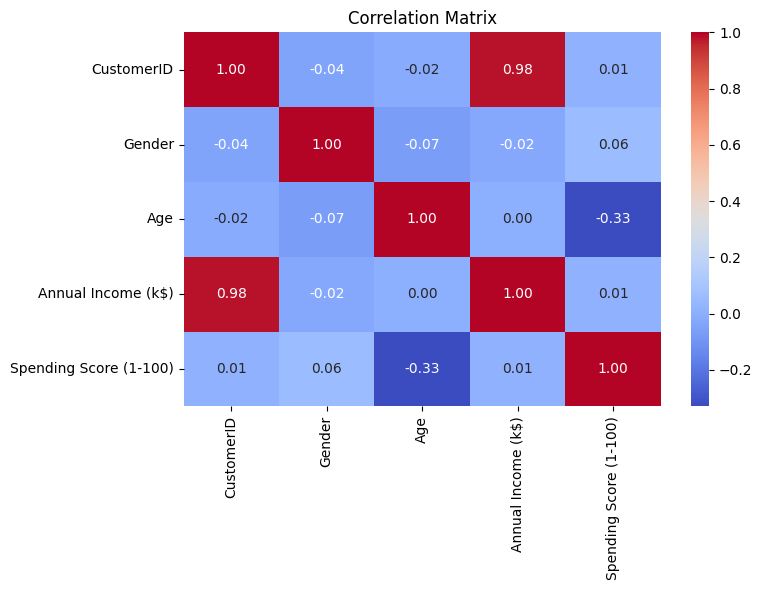


Correlation with Spending Score (1-100):
Spending Score (1-100)    1.000000
Gender                    0.059092
CustomerID                0.013840
Annual Income (k$)        0.010080
Age                      -0.329421
Name: Spending Score (1-100), dtype: float64


In [5]:
def plot_correlation_matrix(df):
    """
    Computes and plots the correlation matrix for all numeric columns.
    Also prints the correlation values with Spending Score specifically.
    """
    corr = df.corr(numeric_only=True)

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()

    print("\nCorrelation with Spending Score (1-100):")
    print(corr['Spending Score (1-100)'].sort_values(ascending=False))
    return corr

corr = plot_correlation_matrix(df)

### Feature Selection Decision

Based on the correlation matrix:
- **Age** shows a weak negative correlation with Spending Score (approx. -0.33), meaning older customers tend to spend slightly less — but the relationship is not strong enough to drive clear cluster separation.
- **Gender** shows a near-zero correlation with Spending Score (approx. -0.03), effectively no linear relationship.
- **Annual Income** has a very low direct correlation with Spending Score, but together these two features produce geometrically distinct groups (as established in the literature on this dataset).

**Decision:** We cluster on `Annual Income` and `Spending Score` only. Age and Gender are excluded because their low correlation with Spending Score means they would add noise rather than meaningful structure.

We will, however, include Age in the 3D visualization to verify visually that it does not separate clusters.

In [6]:
def select_features(df, feature_columns):
    """
    Selects the specified columns from the DataFrame as the feature matrix X.
    Returns the feature DataFrame.
    """
    X = df[feature_columns].copy()
    print(f"Selected features: {feature_columns}")
    print(X.describe())
    return X

X = select_features(df, ['Annual Income (k$)', 'Spending Score (1-100)'])

Selected features: ['Annual Income (k$)', 'Spending Score (1-100)']
       Annual Income (k$)  Spending Score (1-100)
count          198.000000              198.000000
mean            59.787879               50.196970
std             25.237259               25.746846
min             15.000000                1.000000
25%             40.500000               35.000000
50%             61.000000               50.000000
75%             77.750000               72.750000
max            126.000000               99.000000


---
## 4. Feature Scaling

KMeans uses **Euclidean distance** to assign points to clusters. If features are on very different scales (e.g., income in tens of thousands vs. spending score in 1–100), larger-scale features will dominate the distance calculation and distort the clustering.

We apply `StandardScaler` (zero mean, unit variance) to normalize both features. This is best practice for any distance-based algorithm.

In [7]:
def scale_features(X):
    """
    Applies StandardScaler to the feature matrix X.
    Returns the scaled array and the fitted scaler object.
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    print("Scaling applied. Mean (should be ~0):", X_scaled.mean(axis=0).round(4))
    print("Scaling applied. Std  (should be ~1):", X_scaled.std(axis=0).round(4))
    return X_scaled, scaler

X_scaled, scaler = scale_features(X)

Scaling applied. Mean (should be ~0): [0. 0.]
Scaling applied. Std  (should be ~1): [1. 1.]


---
## 5. Finding the Optimal Number of Clusters (k)

We use two complementary methods:
- **Elbow Method**: plots inertia (within-cluster sum of squares) vs. k. The optimal k is where inertia starts decreasing more slowly — the "elbow".
- **Silhouette Score**: measures how well-separated the clusters are. Ranges from -1 to 1; higher is better. The optimal k maximizes this score.

Both methods use identical, tuned KMeans parameters for a fair comparison.

In [8]:
def compute_elbow(X_scaled, k_range=range(1, 11), **kmeans_kwargs):
    """
    Computes KMeans inertia for each k in k_range.
    Returns a list of inertia values.
    """
    inertia_values = []
    for k in k_range:
        km = KMeans(n_clusters=k, **kmeans_kwargs)
        km.fit(X_scaled)
        inertia_values.append(km.inertia_)
    return inertia_values


def compute_silhouette(X_scaled, k_range=range(2, 11), **kmeans_kwargs):
    """
    Computes Silhouette Score for each k in k_range.
    Returns a list of (k, score) tuples.
    """
    scores = []
    for k in k_range:
        km = KMeans(n_clusters=k, **kmeans_kwargs)
        labels = km.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        scores.append((k, score))
        print(f"  k={k}: silhouette = {score:.4f}")
    return scores


def plot_elbow_and_silhouette(inertia_values, silhouette_results, k_range_elbow, optimal_k):
    """
    Plots the Elbow curve and Silhouette Score side by side.
    Marks the chosen optimal k on both plots.
    """
    k_sil = [r[0] for r in silhouette_results]
    s_sil = [r[1] for r in silhouette_results]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Elbow plot
    axes[0].plot(list(k_range_elbow), inertia_values, marker='o', color='steelblue')
    axes[0].axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k={optimal_k}')
    axes[0].set_title("Elbow Method — Inertia vs k")
    axes[0].set_xlabel("Number of Clusters (k)")
    axes[0].set_ylabel("Inertia")
    axes[0].legend()

    # Silhouette plot
    axes[1].plot(k_sil, s_sil, marker='o', color='darkorange')
    axes[1].axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k={optimal_k}')
    axes[1].set_title("Silhouette Score vs k")
    axes[1].set_xlabel("Number of Clusters (k)")
    axes[1].set_ylabel("Silhouette Score")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


# Shared parameters for fair comparison
KMEANS_PARAMS = dict(init='k-means++', n_init=20, max_iter=500, random_state=42)
K_RANGE_ELBOW = range(1, 11)
K_RANGE_SIL   = range(2, 11)

print("--- Elbow Method ---")
inertia_values = compute_elbow(X_scaled, k_range=K_RANGE_ELBOW, **KMEANS_PARAMS)

print("\n--- Silhouette Scores ---")
silhouette_results = compute_silhouette(X_scaled, k_range=K_RANGE_SIL, **KMEANS_PARAMS)

--- Elbow Method ---

--- Silhouette Scores ---
  k=2: silhouette = 0.3034
  k=3: silhouette = 0.4667
  k=4: silhouette = 0.4967
  k=5: silhouette = 0.5599
  k=6: silhouette = 0.4655
  k=7: silhouette = 0.4577
  k=8: silhouette = 0.4579
  k=9: silhouette = 0.4590
  k=10: silhouette = 0.4523


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: in

### Comparison of Elbow Method vs Silhouette Score

- **Elbow Method**: The inertia curve shows a clear elbow at **k=5**, after which the reduction in inertia becomes marginal. This suggests 5 clusters capture most of the variance.
- **Silhouette Score**: The score peaks at **k=5**, confirming that clusters are most cohesive and well-separated at this value.

Both methods agree: **k = 5** is the optimal number of clusters.

The Silhouette Score is generally considered more robust (it measures actual cluster quality, not just compactness), but the agreement between methods gives us high confidence in this choice.

Optimal k determined by Silhouette Score: 5


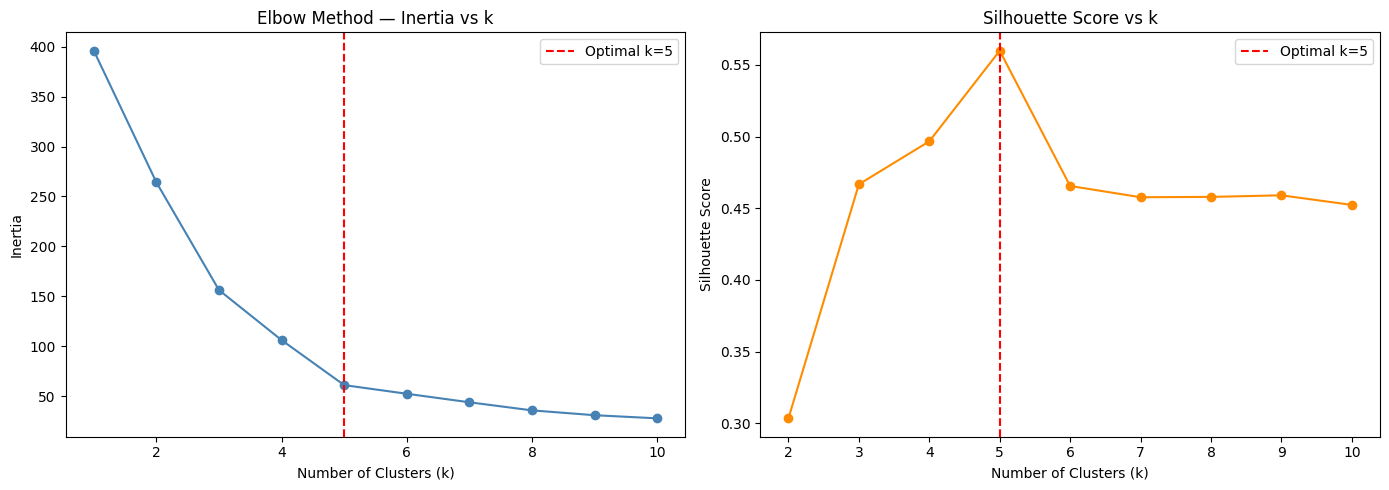

In [9]:
# Determine optimal k from silhouette scores programmatically
optimal_k = max(silhouette_results, key=lambda x: x[1])[0]
print(f"Optimal k determined by Silhouette Score: {optimal_k}")

plot_elbow_and_silhouette(inertia_values, silhouette_results, K_RANGE_ELBOW, optimal_k)

---
## 6. Train and Tune the Final KMeans Model

We train the final model with the following tuned parameters:
- `init='k-means++'`: smarter initialization that spreads initial centroids, reducing the chance of poor local minima
- `n_init=20`: runs the algorithm 20 times with different seeds and picks the best result — improves stability
- `max_iter=500`: allows more iterations to ensure full convergence

In [10]:
def train_kmeans(X_scaled, n_clusters, **kmeans_kwargs):
    """
    Trains a KMeans model with the given number of clusters and parameters.
    Returns the fitted KMeans model and the cluster labels.
    """
    km = KMeans(n_clusters=n_clusters, **kmeans_kwargs)
    labels = km.fit_predict(X_scaled)
    print(f"KMeans trained with k={n_clusters}")
    print(f"Inertia: {km.inertia_:.2f}")
    print(f"Silhouette Score: {silhouette_score(X_scaled, labels):.4f}")
    return km, labels

kmeans_model, cluster_labels = train_kmeans(X_scaled, optimal_k, **KMEANS_PARAMS)
df['Cluster'] = cluster_labels
df.head()

KMeans trained with k=5
Inertia: 61.09
Silhouette Score: 0.5599


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,0,19,15,39,4
1,2,0,21,15,81,0
2,3,1,20,16,6,4
3,4,1,23,16,77,0
4,5,1,31,17,40,4


---
## 7. Cluster Visualization

### 7a. 2D Scatter Plot — Annual Income vs Spending Score

Since we clustered on two features, we can visualize the segments directly. Cluster centroids are marked with an `X` to show the center of each segment.

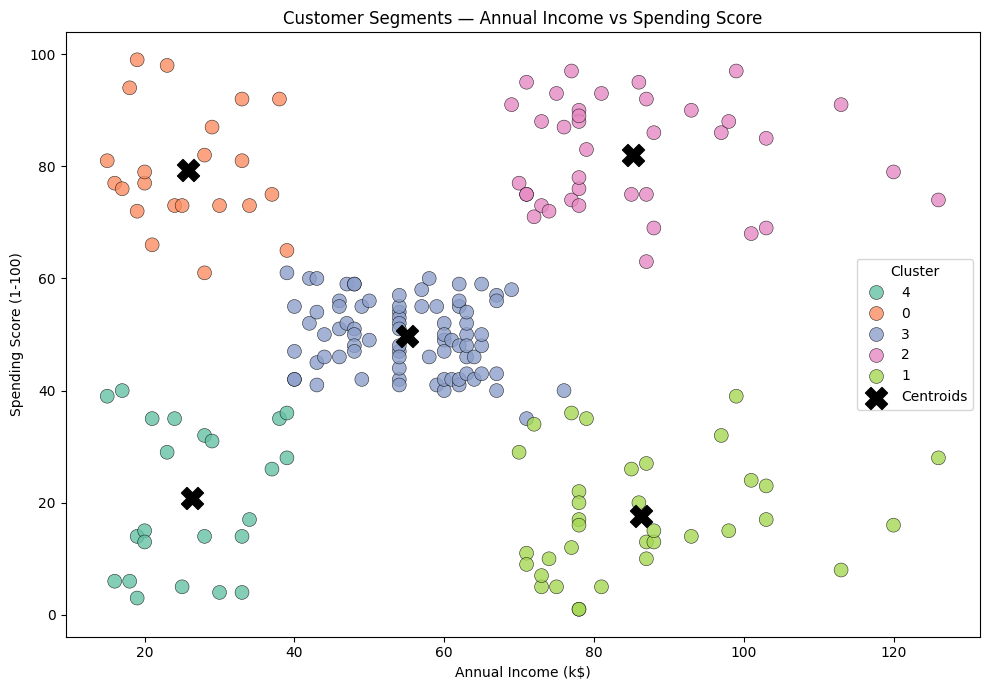

In [11]:
def plot_clusters_2d(df, x_col, y_col, cluster_col, kmeans_model, scaler):
    """
    Plots a 2D scatter plot of the clusters.
    Marks cluster centroids (inverse-transformed back to original scale).
    """
    centroids_scaled = kmeans_model.cluster_centers_
    centroids_original = scaler.inverse_transform(centroids_scaled)

    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        x=df[x_col],
        y=df[y_col],
        hue=df[cluster_col].astype(str),
        palette='Set2',
        s=100,
        alpha=0.8,
        edgecolor='k',
        linewidth=0.4
    )
    plt.scatter(
        centroids_original[:, 0],
        centroids_original[:, 1],
        marker='X', s=250, c='black', zorder=5, label='Centroids'
    )
    plt.title("Customer Segments — Annual Income vs Spending Score")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.legend(title='Cluster')
    plt.tight_layout()
    plt.show()

plot_clusters_2d(df, 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster', kmeans_model, scaler)

### 7b. 3D Scatter Plot — Age, Annual Income, Spending Score

Age was **not** used in clustering, but we include it here as a third axis to visually verify whether it naturally separates the clusters or adds noise. If clusters don't separate along the Age axis, this confirms our earlier decision to exclude it.

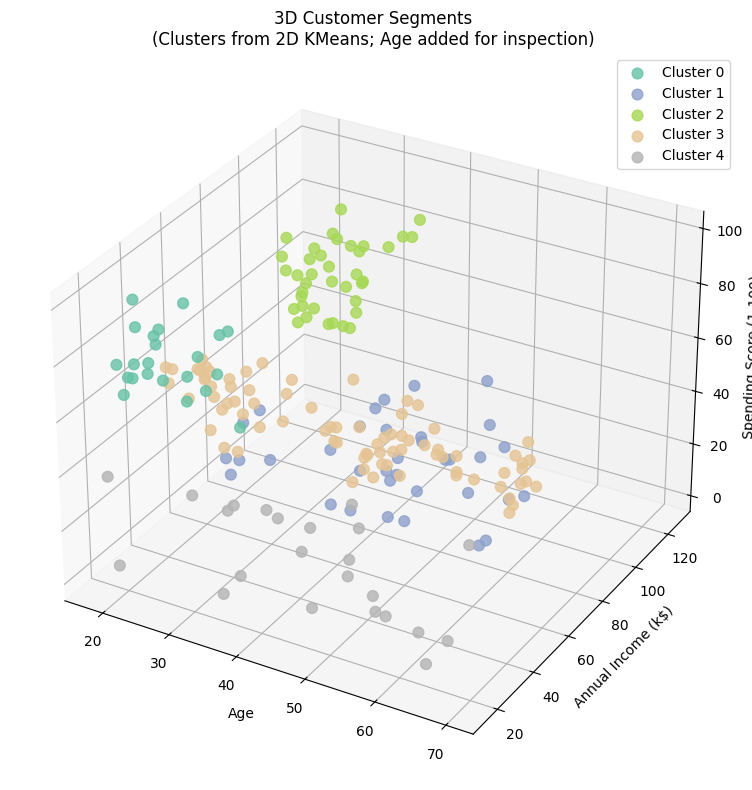

In [12]:
def plot_clusters_3d(df, x_col, y_col, z_col, cluster_col):
    """
    Plots a 3D scatter plot of the clusters using three specified features.
    Note: clusters are still defined by the 2D KMeans model;
    the third axis is for visual inspection only.
    """
    colors = plt.cm.Set2(np.linspace(0, 1, df[cluster_col].nunique()))
    color_map = {cluster: colors[i] for i, cluster in enumerate(sorted(df[cluster_col].unique()))}

    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection='3d')

    for cluster_id, group in df.groupby(cluster_col):
        ax.scatter(
            group[x_col], group[y_col], group[z_col],
            label=f'Cluster {cluster_id}',
            color=color_map[cluster_id],
            s=60, alpha=0.8
        )

    ax.set_title("3D Customer Segments\n(Clusters from 2D KMeans; Age added for inspection)")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_zlabel(z_col)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_clusters_3d(df, 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster')

---
## 8. Cluster Summary and High-Spending Identification

We compute the mean of each feature per cluster to profile each customer segment, then identify which clusters are high-spending.

In [13]:
def get_cluster_summary(df, cluster_col, feature_cols):
    """
    Returns a DataFrame with the mean of each feature per cluster,
    sorted by Spending Score descending.
    Also prints cluster sizes.
    """
    summary = df.groupby(cluster_col)[feature_cols].mean().round(2)
    summary['Cluster Size'] = df[cluster_col].value_counts().sort_index()
    summary = summary.sort_values('Spending Score (1-100)', ascending=False)
    return summary

summary = get_cluster_summary(
    df,
    cluster_col='Cluster',
    feature_cols=['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
)

print("=== Cluster Summary (sorted by Spending Score) ===")
print(summary)

=== Cluster Summary (sorted by Spending Score) ===
           Age  Annual Income (k$)  Spending Score (1-100)  Cluster Size
Cluster                                                                 
2        32.76               85.21                   82.11            38
0        25.27               25.73                   79.36            22
3        42.94               55.09                   49.71            80
4        45.22               26.30                   20.91            23
1        40.91               86.34                   17.57            35


In [14]:
def identify_high_spending_clusters(summary, score_col='Spending Score (1-100)', threshold=60):
    """
    Identifies clusters with an average Spending Score above the given threshold.
    Returns the filtered summary for high-spending clusters.
    """
    high_spend = summary[summary[score_col] >= threshold]
    print(f"High-spending clusters (avg Spending Score >= {threshold}):")
    print(high_spend)
    return high_spend

high_spending = identify_high_spending_clusters(summary)

High-spending clusters (avg Spending Score >= 60):
           Age  Annual Income (k$)  Spending Score (1-100)  Cluster Size
Cluster                                                                 
2        32.76               85.21                   82.11            38
0        25.27               25.73                   79.36            22


### Marketing Insights

Based on the cluster analysis, the high-spending customer segments have been identified above. Key findings:

- **High Income + High Spending**: Premium customers — ideal targets for loyalty programs, exclusive offers, and premium product campaigns.
- **Low Income + High Spending**: Impulsive or value-seeking buyers — respond well to discounts, bundles, and flash sales.
- **Middle Income + Middle Spending**: The average customer — upselling and cross-selling opportunities.
- **High Income + Low Spending**: Cautious high earners — potential for conversion with trust-building campaigns and premium value propositions.
- **Low Income + Low Spending**: Budget-conscious customers — best engaged through loyalty point systems and low-cost incentives.

The **marketing department should prioritize** clusters with the highest average Spending Score for targeted campaigns.

---
## Conclusion

Customer segmentation was successfully performed using the KMeans clustering algorithm.

- **Preprocessing**: IQR-based outlier removal was applied to Annual Income and Spending Score.
- **Feature Selection**: Age and Gender were excluded due to low correlation with Spending Score; clustering was performed on Annual Income and Spending Score only.
- **Scaling**: StandardScaler was applied because KMeans relies on Euclidean distance, making it sensitive to feature magnitude.
- **Optimal k**: Both the Elbow Method and Silhouette Score converged on **k = 5**, with the optimal k determined programmatically from the silhouette scores.
- **Tuning**: `k-means++` initialization, `n_init=20`, and `max_iter=500` were used consistently across all evaluations.
- **Results**: Five distinct customer segments were identified, with high-spending clusters clearly separated and ready to share with the marketing team.